# Deskriptive Analyse

Dieses Notebook beschreibt den Trainingsdatensatz `datasets/modeling/splits/train.parquet`. Es werden keine Modelle trainiert und keine Werte imputiert.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "datasets" / "modeling" / "splits" / "train.parquet").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("train.parquet wurde nicht gefunden.")
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_PATH = PROJECT_ROOT / "datasets" / "modeling" / "splits" / "train.parquet"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "descriptive_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_ROWS = 689_684
REQUIRED_COLUMNS = [
    "delay_target",
    "event_hour",
    "event_weekday",
    "ff_wind_speed_ms",
    "ff_wind_direction_deg",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
    "rr_precipitation_form",
    "is_public_holiday",
    "planned_event_time",
    "station_name",
    "train_type",
    "line_number",
    "concrete_ride_id",
]

WEEKDAY_NAMES = {
    0: "Montag",
    1: "Dienstag",
    2: "Mittwoch",
    3: "Donnerstag",
    4: "Freitag",
    5: "Samstag",
    6: "Sonntag",
}

FEATURE_LABELS = {
    "ff_wind_speed_ms": "Windgeschwindigkeit",
    "ff_wind_direction_deg": "Windrichtung",
    "fx_wind_gust_ms": "Maximale Windspitze",
    "tu_temperature_c": "Temperatur",
    "tu_relative_humidity_pct": "Relative Luftfeuchtigkeit",
    "rr_precipitation_mm": "Niederschlagshöhe",
    "rr_precipitation_indicator": "Niederschlagsindikator",
    "rr_precipitation_form": "Niederschlagsform",
    "is_public_holiday": "Feiertagsindikator",
}

FEATURE_UNITS = {
    "ff_wind_speed_ms": "m/s",
    "ff_wind_direction_deg": "Grad",
    "fx_wind_gust_ms": "m/s",
    "tu_temperature_c": "°C",
    "tu_relative_humidity_pct": "%",
    "rr_precipitation_mm": "mm",
}

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def save_table(frame, filename, index=False):
    path = OUTPUT_DIR / filename
    frame.to_csv(path, index=index, encoding="utf-8-sig")
    return path


def save_figure(fig, filename_stem):
    fig.savefig(OUTPUT_DIR / f"{filename_stem}.png", bbox_inches="tight", dpi=300)
    fig.savefig(OUTPUT_DIR / f"{filename_stem}.pdf", bbox_inches="tight")


def zero_share(series):
    valid = series.dropna()
    return np.nan if valid.empty else valid.eq(0).mean()


train = pd.read_parquet(TRAIN_PATH)
target = pd.to_numeric(train["delay_target"], errors="coerce")

if len(train) != EXPECTED_ROWS:
    warnings.warn(f"Erwartet wurden {EXPECTED_ROWS} Beobachtungen, gefunden wurden {len(train)}.")

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(train.columns))
if missing_columns:
    raise KeyError(f"Benötigte Spalten fehlen: {missing_columns}")

print(f"Datensatz: {TRAIN_PATH.relative_to(PROJECT_ROOT)}")
print(f"Beobachtungen: {len(train):,}".replace(",", "."))
print(f"Outputordner: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


Datensatz: datasets\modeling\splits\train.parquet
Beobachtungen: 689.684
Outputordner: outputs\descriptive_analysis


## Verteilung der Zielvariable

Die Zielvariable wird mit Lage-, Streuungs- und Randkennzahlen beschrieben. Für die Abbildung werden keine Beobachtungen entfernt; der linke Teil zeigt nur den Zentralbereich bis zum 99-%-Quantil.


In [2]:
target_valid = target.dropna()
zero_count = int(target_valid.eq(0).sum())
positive_count = int(target_valid.gt(0).sum())

target_distribution_summary = pd.DataFrame(
    [
        {"kennzahl": "Beobachtungszahl", "wert": len(train)},
        {"kennzahl": "Mittelwert", "wert": target_valid.mean()},
        {"kennzahl": "Standardabweichung", "wert": target_valid.std()},
        {"kennzahl": "Minimum", "wert": target_valid.min()},
        {"kennzahl": "25-%-Quantil", "wert": target_valid.quantile(0.25)},
        {"kennzahl": "Median", "wert": target_valid.median()},
        {"kennzahl": "75-%-Quantil", "wert": target_valid.quantile(0.75)},
        {"kennzahl": "90-%-Quantil", "wert": target_valid.quantile(0.90)},
        {"kennzahl": "95-%-Quantil", "wert": target_valid.quantile(0.95)},
        {"kennzahl": "99-%-Quantil", "wert": target_valid.quantile(0.99)},
        {"kennzahl": "Maximum", "wert": target_valid.max()},
        {"kennzahl": "Schiefe", "wert": target_valid.skew()},
        {"kennzahl": "Anzahl delay_target = 0", "wert": zero_count},
        {"kennzahl": "Anteil delay_target = 0", "wert": zero_count / len(target_valid)},
        {"kennzahl": "Anzahl delay_target > 0", "wert": positive_count},
        {"kennzahl": "Anteil delay_target > 0", "wert": positive_count / len(target_valid)},
    ]
)

save_table(target_distribution_summary, "target_distribution_summary.csv")
display(target_distribution_summary)


,kennzahl,wert
0,Beobachtungszahl,689684.0000
1,Mittelwert,5.4310
2,Standardabweichung,10.0555
3,Minimum,0.0000
4,25-%-Quantil,0.0000
5,Median,2.0000
6,75-%-Quantil,6.0000
7,90-%-Quantil,15.0000
8,95-%-Quantil,23.0000
9,99-%-Quantil,46.0000


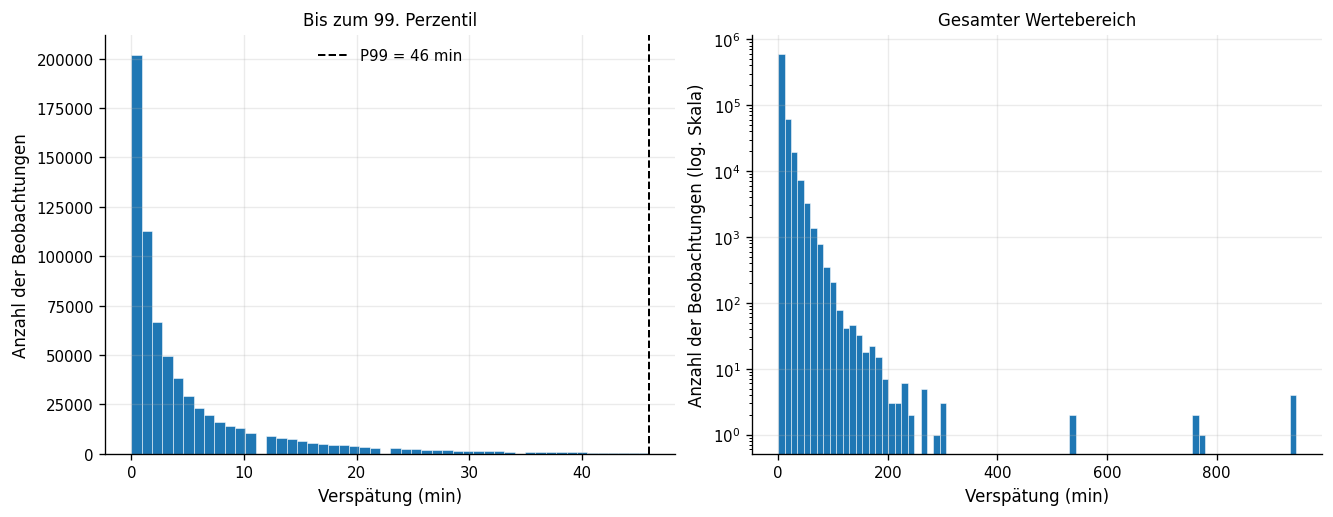

In [3]:
q99 = target_valid.quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].hist(target_valid[target_valid <= q99], bins=50, edgecolor="white", linewidth=0.3)
axes[0].axvline(q99, linestyle="--", linewidth=1.2, color="black", label=f"P99 = {q99:.0f} min")
axes[0].set_title("Bis zum 99. Perzentil")
axes[0].set_xlabel("Verspätung (min)")
axes[0].set_ylabel("Anzahl der Beobachtungen")
axes[0].legend(frameon=False)

axes[1].hist(target_valid, bins=80, edgecolor="white", linewidth=0.3, log=True)
axes[1].set_title("Gesamter Wertebereich")
axes[1].set_xlabel("Verspätung (min)")
axes[1].set_ylabel("Anzahl der Beobachtungen (log. Skala)")

save_figure(fig, "target_distribution_train")
plt.show()


## Zeitliche Muster

Die tatsächliche Haltverspätung wird nach Tagesstunde und Wochentag gruppiert.


In [4]:
def delay_group_summary(frame, group_column):
    return (
        frame.groupby(group_column, dropna=False)["delay_target"]
        .agg(
            beobachtungszahl="size",
            mittelwert="mean",
            median="median",
            q95=lambda series: series.quantile(0.95),
            anteil_delay_target_0=zero_share,
        )
        .reset_index()
    )


delay_by_hour = delay_group_summary(
    pd.DataFrame({"event_hour": train["event_hour"], "delay_target": target}),
    "event_hour",
).set_index("event_hour").reindex(range(24)).rename_axis("event_hour").reset_index()

delay_by_weekday = delay_group_summary(
    pd.DataFrame({"event_weekday": train["event_weekday"], "delay_target": target}),
    "event_weekday",
).set_index("event_weekday").reindex(range(7)).rename_axis("event_weekday").reset_index()
delay_by_weekday.insert(1, "wochentag", delay_by_weekday["event_weekday"].map(WEEKDAY_NAMES))

save_table(delay_by_hour, "delay_by_hour.csv")
save_table(delay_by_weekday, "delay_by_weekday.csv")

display(delay_by_hour)
display(delay_by_weekday)


,event_hour,beobachtungszahl,mittelwert,median,q95,anteil_delay_target_0
0,0,13190,4.4061,1.0000,22.0000,0.3970
1,1,10930,3.8233,1.0000,18.0000,0.4296
2,2,8478,3.5464,1.0000,18.0000,0.4685
3,3,7035,2.7893,1.0000,13.0000,0.4742
4,4,11889,2.6683,1.0000,13.0000,0.4585
5,5,25374,3.4646,1.0000,15.0000,0.3830
6,6,33571,4.0793,1.0000,17.0000,0.3420
7,7,36320,4.5066,2.0000,19.0000,0.3173
8,8,36410,4.5486,2.0000,19.0000,0.2989
9,9,36232,4.7302,2.0000,20.0000,0.3044


,event_weekday,wochentag,beobachtungszahl,mittelwert,median,q95,anteil_delay_target_0
0,0,Montag,104889,5.4143,2.0000,23.0000,0.2916
1,1,Dienstag,106140,5.6968,2.0000,23.0000,0.2766
2,2,Mittwoch,100518,5.4513,2.0000,23.0000,0.2768
3,3,Donnerstag,98903,6.1517,2.0000,25.0000,0.2648
4,4,Freitag,98626,6.1984,2.0000,25.0000,0.2560
5,5,Samstag,95265,5.0272,2.0000,22.0000,0.3068
6,6,Sonntag,85343,3.8255,1.0000,18.0000,0.3927


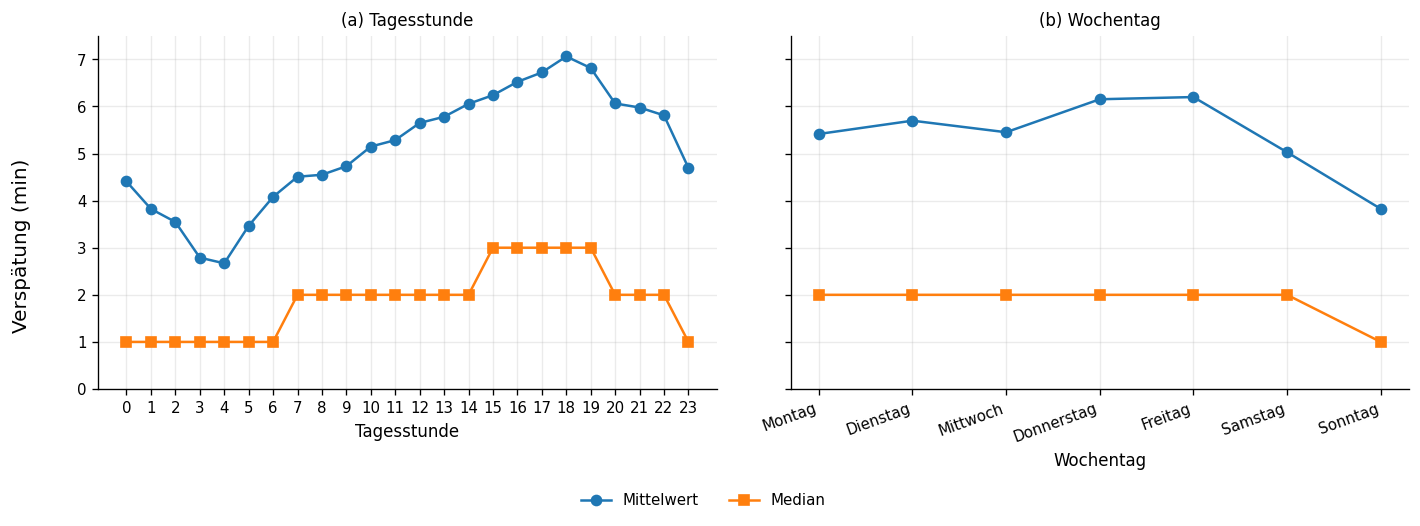

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)

axes[0].plot(delay_by_hour["event_hour"], delay_by_hour["mittelwert"], marker="o", label="Mittelwert")
axes[0].plot(delay_by_hour["event_hour"], delay_by_hour["median"], marker="s", label="Median")
axes[0].set_xticks(range(24))
axes[0].set_title("(a) Tagesstunde")
axes[0].set_xlabel("Tagesstunde")

x = np.arange(len(delay_by_weekday))
axes[1].plot(x, delay_by_weekday["mittelwert"], marker="o", label="Mittelwert")
axes[1].plot(x, delay_by_weekday["median"], marker="s", label="Median")
axes[1].set_xticks(x)
axes[1].set_xticklabels(delay_by_weekday["wochentag"], rotation=20, ha="right")
axes[1].set_title("(b) Wochentag")
axes[1].set_xlabel("Wochentag")

max_time_value = max(
    delay_by_hour[["mittelwert", "median"]].max().max(),
    delay_by_weekday[["mittelwert", "median"]].max().max(),
)
axes[0].set_ylim(0, max(7.5, np.ceil(max_time_value * 2) / 2))
fig.supylabel("Verspätung (min)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.0))
fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.24, wspace=0.12)

save_figure(fig, "delay_by_time_train")
plt.show()


## Verteilung der externen Merkmale

Die Rohmerkmale werden als numerische Kennzahlen beziehungsweise als Häufigkeiten zusammengefasst. Fehlende Werte werden gezählt.


In [6]:
numeric_features = [
    "ff_wind_speed_ms",
    "ff_wind_direction_deg",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
]

external_numeric_summary = pd.DataFrame(
    [
        {
            "merkmal": column,
            "bezeichnung": FEATURE_LABELS[column],
            "einheit": FEATURE_UNITS[column],
            "gueltige_beobachtungen": int(pd.to_numeric(train[column], errors="coerce").notna().sum()),
            "fehlende_werte": int(pd.to_numeric(train[column], errors="coerce").isna().sum()),
            "mittelwert": pd.to_numeric(train[column], errors="coerce").mean(),
            "standardabweichung": pd.to_numeric(train[column], errors="coerce").std(),
            "minimum": pd.to_numeric(train[column], errors="coerce").min(),
            "q25": pd.to_numeric(train[column], errors="coerce").quantile(0.25),
            "median": pd.to_numeric(train[column], errors="coerce").median(),
            "q75": pd.to_numeric(train[column], errors="coerce").quantile(0.75),
            "q95": pd.to_numeric(train[column], errors="coerce").quantile(0.95),
            "q99": pd.to_numeric(train[column], errors="coerce").quantile(0.99),
            "maximum": pd.to_numeric(train[column], errors="coerce").max(),
        }
        for column in numeric_features
    ]
)

save_table(external_numeric_summary, "external_numeric_summary.csv")
display(external_numeric_summary)


,merkmal,bezeichnung,einheit,gueltige_beobachtungen,fehlende_werte,mittelwert,standardabweichung,minimum,q25,median,q75,q95,q99,maximum
0,ff_wind_speed_ms,Windgeschwindigkeit,m/s,684915,4769,3.4217,1.6656,0.2000,2.1000,3.3000,4.5000,6.4000,7.7000,10.7000
1,ff_wind_direction_deg,Windrichtung,Grad,685479,4205,176.9503,82.5044,0.0000,120.0000,150.0000,250.0000,330.0000,360.0000,360.0000
2,fx_wind_gust_ms,Maximale Windspitze,m/s,684915,4769,6.0344,2.9454,0.6000,3.6000,5.7000,7.7000,11.3000,14.1000,34.3000
3,tu_temperature_c,Temperatur,°C,688178,1506,9.8237,7.4742,-12.8000,4.3000,9.0000,14.0000,24.4000,31.6000,39.9000
4,tu_relative_humidity_pct,Relative Luftfeuchtigkeit,%,688087,1597,72.7934,17.5625,18.0000,61.0000,77.0000,87.0000,95.0000,97.0000,100.0000
5,rr_precipitation_mm,Niederschlagshöhe,mm,689378,306,0.0741,0.3661,0.0000,0.0000,0.0000,0.0000,0.4000,1.7000,12.6000


In [7]:
def category_label(column, value):
    if pd.isna(value):
        return "(fehlend)"
    if column == "rr_precipitation_indicator":
        return "Niederschlag" if value == 1 else "kein Niederschlag"
    if column == "is_public_holiday":
        return "Feiertag" if bool(value) else "kein Feiertag"
    if isinstance(value, (int, np.integer)) or (isinstance(value, (float, np.floating)) and float(value).is_integer()):
        return f"Code {int(value)}"
    return str(value)


categorical_rows = []
for column in ["rr_precipitation_indicator", "rr_precipitation_form", "is_public_holiday"]:
    counts = train[column].value_counts(dropna=False)
    for value, count in counts.items():
        categorical_rows.append(
            {
                "merkmal": column,
                "auspraegung": category_label(column, value),
                "beobachtungen": int(count),
                "anteil": count / len(train),
            }
        )

external_categorical_summary = pd.DataFrame(categorical_rows)
save_table(external_categorical_summary, "external_categorical_summary.csv")
display(external_categorical_summary)


,merkmal,auspraegung,beobachtungen,anteil
0,rr_precipitation_indicator,kein Niederschlag,527629,0.7650
1,rr_precipitation_indicator,Niederschlag,161749,0.2345
2,rr_precipitation_indicator,(fehlend),306,0.0004
3,rr_precipitation_form,Code 0,527629,0.7650
4,rr_precipitation_form,Code 6,146173,0.2119
5,rr_precipitation_form,Code 7,8702,0.0126
6,rr_precipitation_form,Code 8,6308,0.0091
7,rr_precipitation_form,Code 4,663,0.0010
8,rr_precipitation_form,(fehlend),209,0.0003
9,is_public_holiday,kein Feiertag,664853,0.9640


## Beobachtete Zusammenhänge mit der Haltverspätung

Die folgenden Auswertungen zeigen deskriptive Gruppenunterschiede der beobachteten `delay_target`-Werte. Sie sind keine Modellvorhersagen und werden nicht kausal interpretiert.


In [8]:
numeric_group_features = [
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "ff_wind_speed_ms",
    "fx_wind_gust_ms",
]


def summarize_delay_by_group(frame, group_column):
    return (
        frame.groupby(group_column, dropna=False, observed=True)["delay_target"]
        .agg(
            beobachtungszahl="size",
            mittelwert_delay_target="mean",
            median_delay_target="median",
            q95_delay_target=lambda series: series.quantile(0.95),
            anteil_delay_target_0=zero_share,
        )
        .reset_index()
    )


numeric_group_tables = []
for column in numeric_group_features:
    values = pd.to_numeric(train[column], errors="coerce")
    work = pd.DataFrame({"wert": values, "delay_target": target}).dropna(subset=["wert", "delay_target"]).copy()
    work["gruppe_intervall"] = pd.qcut(work["wert"], q=5, duplicates="drop")
    work["gruppe_nr"] = work["gruppe_intervall"].cat.codes + 1
    summary = (
        work.groupby(["gruppe_nr", "gruppe_intervall"], observed=True)
        .agg(
            wert_min=("wert", "min"),
            wert_max=("wert", "max"),
            beobachtungszahl=("delay_target", "size"),
            mittelwert_delay_target=("delay_target", "mean"),
            median_delay_target=("delay_target", "median"),
            q95_delay_target=("delay_target", lambda series: series.quantile(0.95)),
            anteil_delay_target_0=("delay_target", zero_share),
        )
        .reset_index()
    )
    summary.insert(0, "merkmal", column)
    summary.insert(1, "bezeichnung", FEATURE_LABELS[column])
    summary.insert(2, "einheit", FEATURE_UNITS[column])
    summary["gruppe"] = "Q" + summary["gruppe_nr"].astype(str)
    summary["wertebereich"] = summary["wert_min"].round(2).astype(str) + " bis " + summary["wert_max"].round(2).astype(str)
    numeric_group_tables.append(
        summary[
            [
                "merkmal",
                "bezeichnung",
                "einheit",
                "gruppe",
                "wertebereich",
                "wert_min",
                "wert_max",
                "beobachtungszahl",
                "mittelwert_delay_target",
                "median_delay_target",
                "q95_delay_target",
                "anteil_delay_target_0",
            ]
        ]
    )

observed_delay_by_numeric_features = pd.concat(numeric_group_tables, ignore_index=True)
save_table(observed_delay_by_numeric_features, "observed_delay_by_numeric_features.csv")
display(observed_delay_by_numeric_features)


,merkmal,bezeichnung,einheit,gruppe,wertebereich,wert_min,wert_max,beobachtungszahl,mittelwert_delay_target,median_delay_target,q95_delay_target,anteil_delay_target_0
0,tu_temperature_c,Temperatur,°C,Q1,-12.8 bis 3.5,-12.8000,3.5000,140949,4.6849,2.0000,20.0000,0.3161
1,tu_temperature_c,Temperatur,°C,Q2,3.6 bis 7.0,3.6000,7.0000,136113,5.6423,2.0000,23.0000,0.2804
2,tu_temperature_c,Temperatur,°C,Q3,7.1 bis 10.8,7.1000,10.8000,138685,5.4498,2.0000,23.0000,0.2908
3,tu_temperature_c,Temperatur,°C,Q4,10.9 bis 15.5,10.9000,15.5000,135748,4.9401,2.0000,21.0000,0.3053
4,tu_temperature_c,Temperatur,°C,Q5,15.6 bis 39.9,15.6000,39.9000,136683,6.3747,2.0000,27.0000,0.2714
5,tu_relative_humidity_pct,Relative Luftfeuchtigkeit,%,Q1,18.0 bis 56.0,18.0000,56.0000,139073,6.0443,2.0000,25.0000,0.2710
6,tu_relative_humidity_pct,Relative Luftfeuchtigkeit,%,Q2,57.0 bis 72.0,57.0000,72.0000,144919,5.2509,2.0000,22.0000,0.2920
7,tu_relative_humidity_pct,Relative Luftfeuchtigkeit,%,Q3,73.0 bis 81.0,73.0000,81.0000,133979,5.2853,2.0000,23.0000,0.3034
8,tu_relative_humidity_pct,Relative Luftfeuchtigkeit,%,Q4,82.0 bis 89.0,82.0000,89.0000,145827,5.5169,2.0000,23.0000,0.2872
9,tu_relative_humidity_pct,Relative Luftfeuchtigkeit,%,Q5,90.0 bis 100.0,90.0000,100.0000,124289,4.9209,2.0000,21.0000,0.3139


In [9]:
categorical_group_tables = []
for column in ["rr_precipitation_indicator", "rr_precipitation_form", "is_public_holiday"]:
    work = pd.DataFrame({"auspraegung_roh": train[column], "delay_target": target}).dropna(subset=["delay_target"]).copy()
    work = work.dropna(subset=["auspraegung_roh"]).copy()
    if work["auspraegung_roh"].nunique() < 2:
        continue
    work["auspraegung"] = work["auspraegung_roh"].map(lambda value: category_label(column, value))
    summary = summarize_delay_by_group(work, "auspraegung")
    summary.insert(0, "merkmal", column)
    summary.insert(1, "bezeichnung", FEATURE_LABELS[column])
    categorical_group_tables.append(summary)

observed_delay_by_categorical_features = pd.concat(categorical_group_tables, ignore_index=True)
save_table(observed_delay_by_categorical_features, "observed_delay_by_categorical_features.csv")
display(observed_delay_by_categorical_features)


,merkmal,bezeichnung,auspraegung,beobachtungszahl,mittelwert_delay_target,median_delay_target,q95_delay_target,anteil_delay_target_0
0,rr_precipitation_indicator,Niederschlagsindikator,Niederschlag,161749,5.7137,2.0000,24.0000,0.2760
1,rr_precipitation_indicator,Niederschlagsindikator,kein Niederschlag,527629,5.3443,2.0000,23.0000,0.2979
2,rr_precipitation_form,Niederschlagsform,Code 0,527629,5.3443,2.0000,23.0000,0.2979
3,rr_precipitation_form,Niederschlagsform,Code 4,663,9.1629,3.0000,38.0000,0.2685
4,rr_precipitation_form,Niederschlagsform,Code 6,146173,5.6946,2.0000,23.0000,0.2765
5,rr_precipitation_form,Niederschlagsform,Code 7,8702,5.9352,2.0000,25.0000,0.2626
6,rr_precipitation_form,Niederschlagsform,Code 8,6308,5.5476,2.0000,24.0000,0.2849
7,is_public_holiday,Feiertagsindikator,Feiertag,24831,3.4515,1.0000,16.0000,0.4149
8,is_public_holiday,Feiertagsindikator,kein Feiertag,664853,5.5049,2.0000,23.0000,0.2882


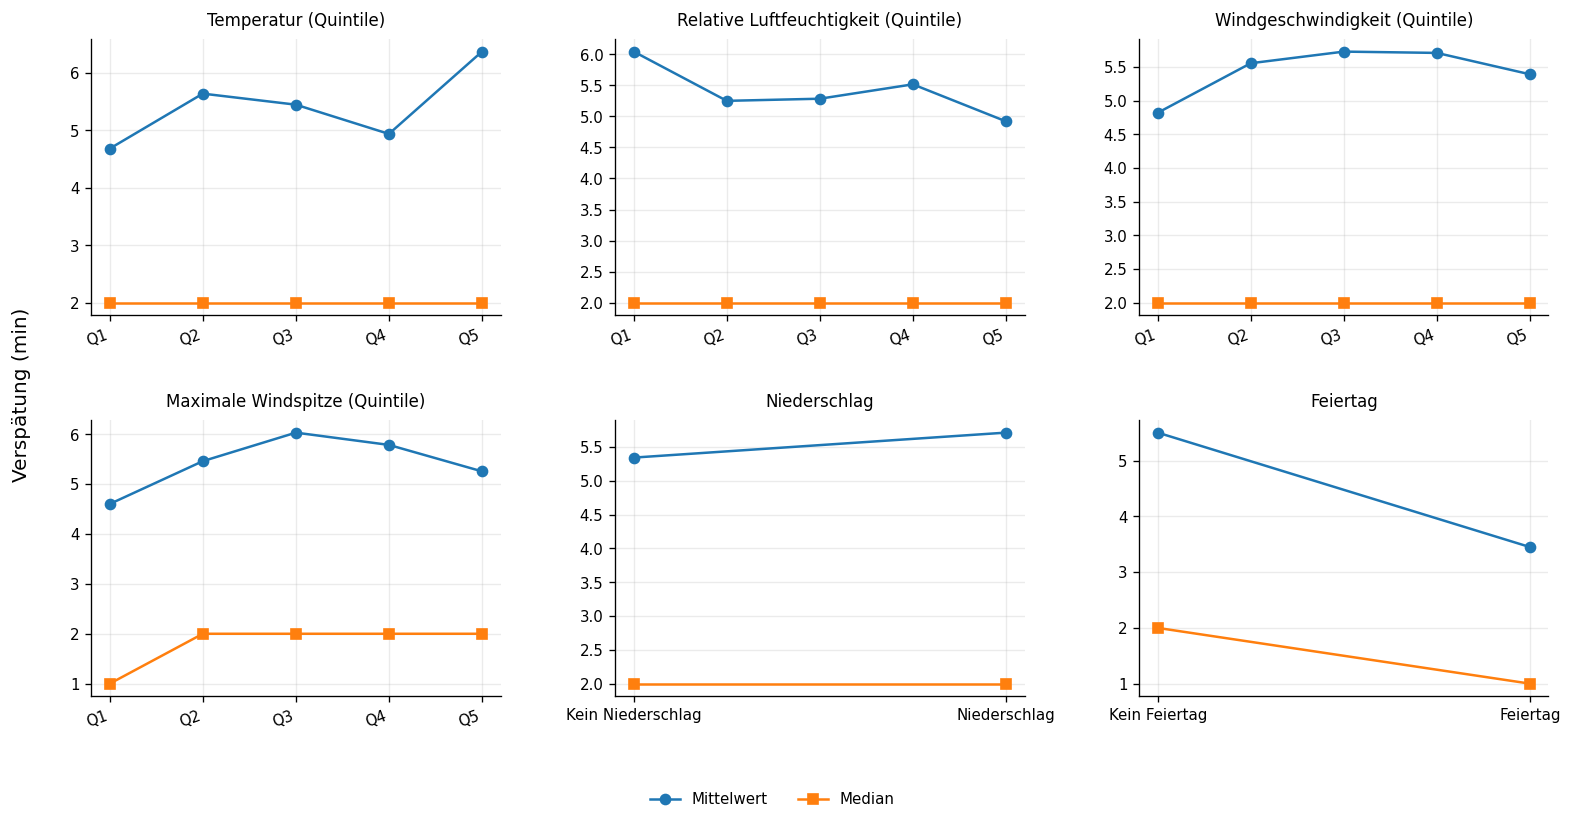

In [10]:
plot_specs = [
    ("Temperatur (Quintile)", observed_delay_by_numeric_features.query("merkmal == 'tu_temperature_c'"), "gruppe"),
    ("Relative Luftfeuchtigkeit (Quintile)", observed_delay_by_numeric_features.query("merkmal == 'tu_relative_humidity_pct'"), "gruppe"),
    ("Windgeschwindigkeit (Quintile)", observed_delay_by_numeric_features.query("merkmal == 'ff_wind_speed_ms'"), "gruppe"),
    ("Maximale Windspitze (Quintile)", observed_delay_by_numeric_features.query("merkmal == 'fx_wind_gust_ms'"), "gruppe"),
    ("Niederschlag", observed_delay_by_categorical_features.query("merkmal == 'rr_precipitation_indicator'"), "auspraegung"),
    ("Feiertag", observed_delay_by_categorical_features.query("merkmal == 'is_public_holiday'"), "auspraegung"),
]

label_replacements = {
    "kein Niederschlag": "Kein Niederschlag",
    "Niederschlag": "Niederschlag",
    "kein Feiertag": "Kein Feiertag",
    "Feiertag": "Feiertag",
}

fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.4))
axes = axes.ravel()

for ax, (title, plot_data, label_column) in zip(axes, plot_specs):
    plot_data = plot_data.reset_index(drop=True).copy()
    labels = plot_data[label_column].replace(label_replacements)
    if title == "Niederschlag":
        order = {"Kein Niederschlag": 0, "Niederschlag": 1}
        plot_data = plot_data.assign(_order=labels.map(order)).sort_values("_order").drop(columns="_order").reset_index(drop=True)
        labels = plot_data[label_column].replace(label_replacements)
    if title == "Feiertag":
        order = {"Kein Feiertag": 0, "Feiertag": 1}
        plot_data = plot_data.assign(_order=labels.map(order)).sort_values("_order").drop(columns="_order").reset_index(drop=True)
        labels = plot_data[label_column].replace(label_replacements)
    x = np.arange(len(plot_data))
    ax.plot(x, plot_data["mittelwert_delay_target"], marker="o", label="Mittelwert")
    ax.plot(x, plot_data["median_delay_target"], marker="s", label="Median")
    ax.set_title(title, pad=8)
    ax.set_xticks(x)
    rotation = 0 if len(labels) <= 2 else 20
    ax.set_xticklabels(labels, rotation=rotation, ha="center" if rotation == 0 else "right")
    ax.set_xlabel("")

fig.supylabel("Verspätung (min)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.02))
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.16, hspace=0.38, wspace=0.28)

save_figure(fig, "observed_delay_by_external_features_train")
plt.show()


## Kurze Plausibilitätsprüfung

Die Zielvariable wird kurz auf ganzzahlige Minutenwerte, vollständige Ausprägungen im Bereich 0 bis 60 und extreme Werte geprüft.


In [11]:
target_integer = np.isclose(target_valid % 1, 0).all()
target_integer_values = target_valid.round().astype(int)
frequency_0_60 = target_integer_values.value_counts().reindex(range(61), fill_value=0).sort_index()
missing_0_60 = frequency_0_60[frequency_0_60.eq(0)].index.tolist()
delay_11_count = int(frequency_0_60.loc[11])
over_120_count = int(target_valid.gt(120).sum())

extreme_columns = [
    column
    for column in [
        "id",
        "delay_target",
        "planned_event_time",
        "station_name",
        "train_type",
        "line_number",
        "concrete_ride_id",
    ]
    if column in train.columns
]
top_10_extremes = train.sort_values("delay_target", ascending=False, kind="mergesort").head(10)[extreme_columns]

plausibility_summary = pd.DataFrame(
    [
        {"pruefung": "delay_target ganzzahlig", "ergebnis": bool(target_integer)},
        {"pruefung": "Häufigkeit delay_target = 11", "ergebnis": delay_11_count},
        {"pruefung": "fehlende ganzzahlige Werte 0 bis 60", "ergebnis": "keine" if not missing_0_60 else missing_0_60},
        {"pruefung": "Beobachtungen mit delay_target > 120", "ergebnis": over_120_count},
    ]
)

display(plausibility_summary)
display(top_10_extremes)

# Eine frühere Rückverfolgung zeigte, dass die höchsten Werte bereits vorgelagert als delay_in_min vorhanden waren.


,pruefung,ergebnis
0,delay_target ganzzahlig,True
1,Häufigkeit delay_target = 11,10349
2,fehlende ganzzahlige Werte 0 bis 60,keine
3,Beobachtungen mit delay_target > 120,207


,id,delay_target,planned_event_time,station_name,train_type,line_number,concrete_ride_id
658840,-2501053104132656396-2606181843-16,945.0000,2026-06-18 19:36:00,Köln/Bonn Flughafen,S,S19,-2501053104132656396-2606181843
658795,-2501053104132656396-2606181843-12,944.0000,2026-06-18 19:21:00,Köln Hbf,S,S19,-2501053104132656396-2606181843
658801,-2501053104132656396-2606181843-13,944.0000,2026-06-18 19:24:00,Köln Messe/Deutz,S,S19,-2501053104132656396-2606181843
658864,-2501053104132656396-2606181843-19,944.0000,2026-06-18 19:47:00,Troisdorf,S,S19,-2501053104132656396-2606181843
657778,-6862454265654933900-2606181313-11,772.0000,2026-06-18 13:50:00,Köln Hbf,S,S12,-6862454265654933900-2606181313
657736,-7383071725037654441-2606181124-29,762.0000,2026-06-18 12:47:00,Köln Hbf,S,S11,-7383071725037654441-2606181124
657739,-7383071725037654441-2606181124-30,762.0000,2026-06-18 12:50:00,Köln Messe/Deutz,S,S11,-7383071725037654441-2606181124
657616,-1455150519241166787-2606181228-32,541.0000,2026-06-18 14:01:00,Köln Messe/Deutz,S,S6,-1455150519241166787-2606181228
657619,-1455150519241166787-2606181228-33,541.0000,2026-06-18 14:04:00,Köln Hbf,S,S6,-1455150519241166787-2606181228
657618,3572164665469424629-2606181628-32,302.0000,2026-06-18 18:01:00,Köln Messe/Deutz,S,S6,3572164665469424629-2606181628


In [12]:
hour_high_mean = delay_by_hour.loc[delay_by_hour["mittelwert"].idxmax()]
hour_low_mean = delay_by_hour.loc[delay_by_hour["mittelwert"].idxmin()]
weekday_high_mean = delay_by_weekday.loc[delay_by_weekday["mittelwert"].idxmax()]
weekday_low_mean = delay_by_weekday.loc[delay_by_weekday["mittelwert"].idxmin()]

precip_valid = train["rr_precipitation_indicator"].dropna()
holiday_valid = train["is_public_holiday"].dropna()

descriptive_summary = pd.DataFrame(
    [
        {"kennzahl": "Mittelwert delay_target", "wert": target_valid.mean()},
        {"kennzahl": "Median delay_target", "wert": target_valid.median()},
        {"kennzahl": "Schiefe delay_target", "wert": target_valid.skew()},
        {"kennzahl": "Nullanteil delay_target", "wert": zero_count / len(target_valid)},
        {"kennzahl": "P95 delay_target", "wert": target_valid.quantile(0.95)},
        {"kennzahl": "P99 delay_target", "wert": target_valid.quantile(0.99)},
        {"kennzahl": "Maximum delay_target", "wert": target_valid.max()},
        {"kennzahl": "Tagesstunde höchster Mittelwert", "wert": int(hour_high_mean["event_hour"])},
        {"kennzahl": "Tagesstunde niedrigster Mittelwert", "wert": int(hour_low_mean["event_hour"])},
        {"kennzahl": "Wochentag höchster Mittelwert", "wert": weekday_high_mean["wochentag"]},
        {"kennzahl": "Wochentag niedrigster Mittelwert", "wert": weekday_low_mean["wochentag"]},
        {"kennzahl": "Anteil Beobachtungen mit Niederschlag", "wert": precip_valid.eq(1).mean()},
        {"kennzahl": "Anteil Feiertagsbeobachtungen", "wert": holiday_valid.eq(True).mean()},
    ]
)

save_table(descriptive_summary, "descriptive_summary.csv")
display(descriptive_summary)


,kennzahl,wert
0,Mittelwert delay_target,5.4310
1,Median delay_target,2.0000
2,Schiefe delay_target,11.1642
3,Nullanteil delay_target,0.2928
4,P95 delay_target,23.0000
5,P99 delay_target,46.0000
6,Maximum delay_target,945.0000
7,Tagesstunde höchster Mittelwert,18
8,Tagesstunde niedrigster Mittelwert,4
9,Wochentag höchster Mittelwert,Freitag
